# Tutorial de Clasificare K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) este un algoritm de învățare automată supervizată folosit pentru clasificare și regresie. Este un algoritm simplu și intuitiv care se bazează pe ideea că punctele de date similare tind să aparțină aceleiași clase.

## 1. Teorie și Definiții

### Ce este K-Nearest Neighbors (KNN)?

KNN este un algoritm de clasificare care atribuie o etichetă unui punct de date bazându-se pe etichetele celor `K` vecini cei mai apropiați. Algoritmul este **lazy**, adică nu învață un model explicit, ci stochează toate datele de antrenament și face predicții la momentul inferenței.

### Pași ai Algoritmului KNN:

1. **Calculul Distanțelor**: Calculează distanța dintre punctul de test și toate punctele de antrenament.

2. **Selectarea Vecinilor**: Selectează cei `K` vecini cei mai apropiați.

3. **Votarea**: Pentru clasificare, atribuie eticheta cea mai comună dintre cei `K` vecini. Pentru regresie, calculează media valorilor vecinilor.

### Concepte Cheie:

- **Distanța**: Măsura utilizată pentru a determina vecinii cei mai apropiați (de exemplu, distanța Euclideană).

- **K**: Numărul de vecini luați în considerare pentru predicție.

- **Lazy Learning**: Algoritmul nu învață un model explicit, ci face predicții bazându-se direct pe datele de antrenament.

## 2. Implementare de la Zero

Să implementăm KNN de la zero folosind NumPy.

In [1]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k=3):
        self.k = k  # Numarul de vecini

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        predictions = [self._predict(x) for x in X_test]
        return np.array(predictions)

    def _predict(self, x):
        # Calculul distantelor
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]

        # Selectarea celor k vecini cei mai apropiati
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Votarea: atribuirea etichetei celei mai comune
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

### Exemplu de Utilizare

In [2]:
# Generare date de exemplu
np.random.seed(42)
X_train = np.random.rand(100, 2) * 10
y_train = np.random.randint(0, 2, 100)

X_test = np.random.rand(5, 2) * 10

# Aplicare KNN
knn = KNN(k=3)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

print("Predictii:", predictions)

Predictii: [1 1 0 0 0]


## 3. Exerciții

### Exercițiul 1: Implementare KNN pe un Set de Date Nou

Generează un set de date cu 3 clase folosind următorul cod și aplică KNN:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Create the data
np.random.seed(123)
X_train = np.vstack([
    np.random.normal(loc=[0, 0], scale=1, size=(100, 2)),
    np.random.normal(loc=[5, 5], scale=1, size=(100, 2)),
    np.random.normal(loc=[10, 10], scale=1, size=(100, 2))
])
y_train = np.hstack([np.zeros(100), np.ones(100), np.full(100, 2)])

X_test = np.random.rand(10, 2) * 10

# Train a KNN model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Make predictions for X_test
predictions = model.predict(X_test)

### Exercițiul 2: Vizualizare Vecini

Vizualizează punctele de test și vecinii lor cei mai apropiați.

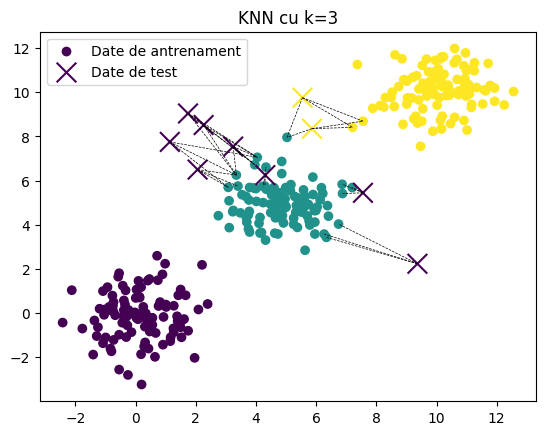

In [4]:

# Plot function
def plot_knn(X_train, y_train, X_test, predictions, k):
    # Ensure X_test and predictions have the same length
    if X_test.shape[0] != len(predictions):
        raise ValueError(f"Number of test points ({X_test.shape[0]}) does not match the number of predictions ({len(predictions)})")

    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', label='Date de antrenament')
    plt.scatter(X_test[:, 0], X_test[:, 1], c=predictions, cmap='viridis', marker='x', s=200, label='Date de test')

    for i, x in enumerate(X_test):
        distances = [np.linalg.norm(x - x_train) for x_train in X_train]
        k_indices = np.argsort(distances)[:k]
        for j in k_indices:
            plt.plot([x[0], X_train[j][0]], [x[1], X_train[j][1]], 'k--', linewidth=0.5)

    plt.legend()
    plt.title(f'KNN cu k={k}')
    plt.show()

# Plot the results
plot_knn(X_train, y_train, X_test, predictions, k=3)

### Exercițiul 3: Comparație cu Scikit-Learn

Compară implementarea ta cu clasa `KNeighborsClassifier` din Scikit-Learn. Folosește următorul cod pentru a rula KNN din Scikit-Learn:

In [5]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=3)
sklearn_knn.fit(X_train, y_train)
sklearn_predictions = sklearn_knn.predict(X_test)

print("Predictii Scikit-Learn:", sklearn_predictions)

Predictii Scikit-Learn: [1. 1. 2. 1. 2. 1. 1. 1. 1. 1.]


## 4. Concluzie

În acest tutorial, am învățat despre algoritmul K-Nearest Neighbors (KNN), l-am implementat de la zero și l-am aplicat pe un set de date de exemplu. Am explorat, de asemenea, exerciții pentru a consolida înțelegerea, inclusiv vizualizarea vecinilor și comparația cu Scikit-Learn.

KNN este un algoritm simplu și eficient pentru sarcini de clasificare și regresie. Cu toate acestea, are limitări, cum ar fi costul computațional ridicat pentru seturi de date mari și sensibilitatea la alegerea valorii lui `K`. Tehnicile de normalizare a datelor și alegerea optimă a lui `K` pot îmbunătăți performanța algoritmului.